## ECE226 Final Project: Hardware-Software Co-design & Custom Accelerators
## Group 19 Team Members: Sean Lipps, Pranav Mekkoth, Jaehyung Lim

In [68]:
!source /tools/Xilinx/Vitis_HLS/2024.1/settings64.sh
!source /opt/xilinx/xrt/setup.sh

Autocomplete enabled for the xbutil command
Autocomplete enabled for the xbmgmt command
XILINX_XRT        : /opt/xilinx/xrt
PATH              : /opt/xilinx/xrt/bin:/home/j.lim.473/miniconda3/envs/hls4ml-tutorial/bin:/home/j.lim.473/.vscode-server/cli/servers/Stable-ce099c1ed25d9eb3076c11e4a280f3eb52b4fbeb/server/bin/remote-cli:/tools/Xilinx/Vitis_HLS/2024.1/bin:/tools/Xilinx/Model_Composer/2024.1/bin:/tools/Xilinx/Vitis/2024.1/bin:/tools/Xilinx/Vitis/2024.1/gnu/microblaze/lin/bin:/tools/Xilinx/Vitis/2024.1/gnu/microblaze/linux_toolchain/lin64_le/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch32/lin/gcc-arm-linux-gnueabi/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch32/lin/gcc-arm-none-eabi/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch64/lin/aarch64-linux/bin:/tools/Xilinx/Vitis/2024.1/gnu/aarch64/lin/aarch64-none/bin:/tools/Xilinx/Vitis/2024.1/gnu/armr5/lin/gcc-arm-none-eabi/bin:/tools/Xilinx/Vitis/2024.1/aietools/bin:/tools/Xilinx/Vitis/2024.1/gnu/riscv/lin/riscv64-unknown-elf/bin:/tools/Xilinx/Vivado/

## Importing UCI HAR dataset

In [ ]:
import os
import requests
import zipfile
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical

# Download and Extract the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_name = "UCI_HAR_Dataset.zip"
folder_name = "UCI HAR Dataset"

if not os.path.exists(folder_name):
    print("Downloading dataset...")
    r = requests.get(url)
    with open(zip_name, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall()
    print("Extraction complete.")

# Helper function to load the 9 inertial signals
def load_signals(subset):
    # The 9 signals: 3-axis Total Accel, 3-axis Body Accel, 3-axis Gyro
    signals_paths = [
        'total_acc_x_', 'total_acc_y_', 'total_acc_z_',
        'body_acc_x_', 'body_acc_y_', 'body_acc_z_',
        'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_'
    ]
    
    signals = []
    for sig in signals_paths:
        path = f"{folder_name}/{subset}/Inertial Signals/{sig}{subset}.txt"
        # Read the 128-column file
        data = pd.read_csv(path, header=None, delim_whitespace=True)
        signals.append(data.values)
        
    # Transpose to get shape (Samples, Timesteps, Channels) -> (N, 128, 9)
    return np.transpose(np.array(signals), (1, 2, 0))

# Load Labels
def load_y(subset):
    path = f"{folder_name}/{subset}/y_{subset}.txt"
    y = pd.read_csv(path, header=None, delim_whitespace=True)
    return to_categorical(y.values - 1, num_classes=6)

# Final Data Preparation
x_train = load_signals('train')
y_train = load_y('train')
x_test = load_signals('test')
y_test = load_y('test')

print(f"x_train shape: {x_train.shape}") # (7352, 128, 9)
print(f"y_train shape: {y_train.shape}") # (7352, 6)

## Building Model using a single Conv1D block

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Activation, GlobalMaxPooling1D, Dense, Input

model = Sequential([
    # Input: 128 time steps, 9 sensor channels
    Input(shape=(128, 9)),
    
    # Simple 1D Conv
    Conv1D(16, kernel_size=3, padding='same', name='conv1'),
    Activation('relu'),
    
    # Bottleneck the data immediately to 16 values
    GlobalMaxPooling1D(),
    
    # Final classification (6 activities)
    Dense(6, activation='softmax')
])

## Training the model
We use Adam optimizer with categorical crossentropy loss.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Define the schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.006,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

# Pass the schedule to the optimizer
adam = Adam(learning_rate=lr_schedule)

model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(
    x_train,
    y_train,
    batch_size=1024,
    epochs=30,
    validation_split=0.25,
    shuffle=True
)

## Checking the model's performance

In [89]:
!pip3 install pyJoules

In [90]:
!lscpu | grep "Model name"

Model name:                              AMD Ryzen Threadripper PRO 7985WX 64-Cores


In [ ]:
import numpy as np
import time
import tracemalloc
import psutil
from sklearn.metrics import accuracy_score, roc_curve, auc

# --- 7985WX SPECIFIC CONFIG ---
# high baseline power draw.
SERVER_TDP_WATTS = 350   # Thermal Design Power for 7985WX
IDLE_POWER_WATTS = 80    # Estimated baseline for the TRX50/WRX90 platform

# Warm-up run to initialize the model on the hardware
_ = model.predict(x_test, verbose=0)

# --- Start Measurement ---
tracemalloc.start()
# Get a baseline of CPU usage (non-blocking)
psutil.cpu_percent(interval=None) 
start_time = time.perf_counter()

y_keras = model.predict(x_test, verbose=0)

end_time = time.perf_counter()
# Capture average CPU load during the 'predict' window
cpu_load = psutil.cpu_percent(interval=None) / 100.0
_, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()
# --- End Measurement ---

total_time = end_time - start_time
time_per_sample = total_time / len(x_test)

# Formula: Base Power + (Scaling Core Power * Load)
active_scaling_range = SERVER_TDP_WATTS - IDLE_POWER_WATTS
estimated_power_watts = IDLE_POWER_WATTS + (cpu_load * active_scaling_range)
total_joules = estimated_power_watts * total_time

# --- Output Performance ---
print(f"Total Inference Time: {total_time:.4f} seconds")
print(f"Latency per sample: {time_per_sample * 1000:.4f} ms")
print(f"Peak CPU Memory Usage: {peak_memory / 10**6:.4f} MB")

# --- Output Power Estimation ---
print(f"\n--- CPU Power Performance (Threadripper PRO 7985WX) ---")
print(f"Average CPU Load: {cpu_load*100:.2f}%")
print(f"Estimated Power: {estimated_power_watts:.2f} Watts")
print(f"Total Energy Consumed: {total_joules:.6f} Joules")

# --- Accuracy and Metrics ---
acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))
print(f"\nOverall Accuracy: {acc:.4f}")

print("\nNumerical ROC/AUC Performance:")
print("-" * 30)
activities = ['Walking', 'Walking Up', 'Walking Down', 'Sitting', 'Standing', 'Laying']

for i in range(len(activities)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_keras[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"Activity {activities[i]:<15} AUC: {roc_auc:.4f}")

Total Inference Time: 0.1370 seconds
Latency per sample: 0.0465 ms
Peak CPU Memory Usage: 40.7449 MB

--- CPU Power Performance (Threadripper PRO 7985WX) ---
Average CPU Load: 10.80%
Estimated Power: 109.16 Watts
Total Energy Consumed: 14.959394 Joules

Overall Accuracy: 0.8639

Numerical ROC/AUC Performance:
------------------------------
Activity Walking         AUC: 0.9807
Activity Walking Up      AUC: 0.9843
Activity Walking Down    AUC: 0.9946
Activity Sitting         AUC: 0.9663
Activity Standing        AUC: 0.9742
Activity Laying          AUC: 0.9955


## Converting the model to FPGA firmware with hls4ml

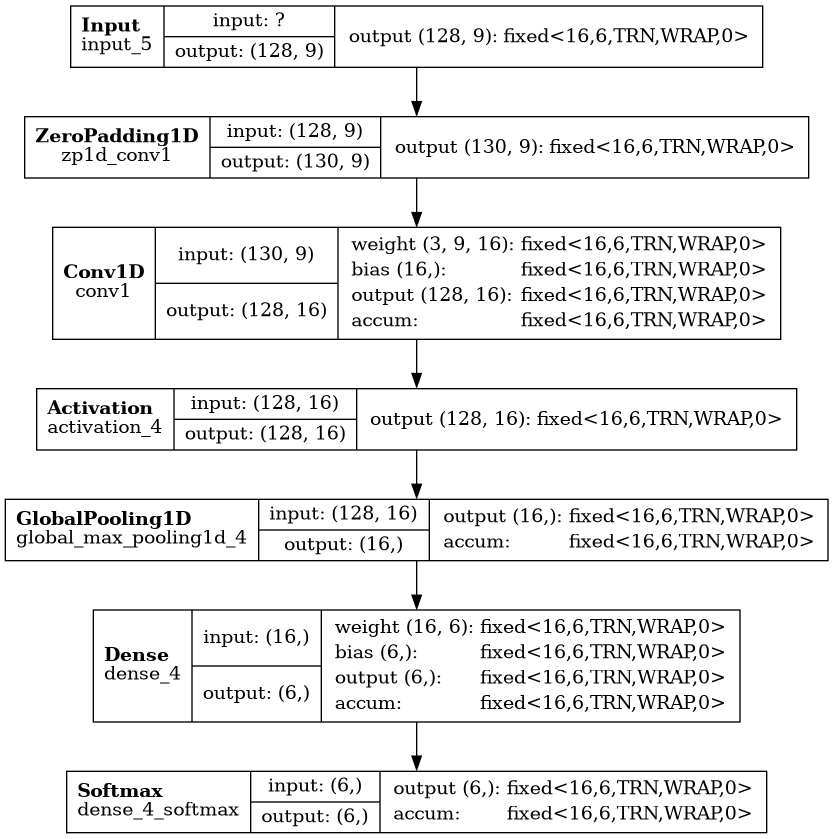

In [92]:
import hls4ml
import shutil
import os


# Setup hls4ml config
config = hls4ml.utils.config_from_keras_model(model, granularity='model')

# Convert and Write
hls_model = hls4ml.converters.convert_from_keras_model(
    model, 
    hls_config=config, 
    backend='Vitis', 
    io_type='io_stream',
    output_dir='model_1/hls4ml_prj', 
    part='xcu250-figd2104-2L-e'
)

hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)


# Compiling and Predicting

In [93]:
hls_model.compile()
x_test = np.ascontiguousarray(x_test)
y_hls = hls_model.predict(x_test)

## Compare the hls4ml model accuracy with Keras model accuracy

In [94]:
# Print Accuracy Comparison
keras_acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))
hls_acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))

print(f"Keras Accuracy:  {keras_acc:.4f}")
print(f"hls4ml Accuracy: {hls_acc:.4f}")

# Numerical ROC/AUC Comparison
print("\nNumerical AUC Comparison (Keras vs hls4ml):")
print("-" * 55)
print(f"{'Activity':<15} | {'Keras AUC':<12} | {'hls4ml AUC':<12}")
print("-" * 55)

n_classes = 6
activities = ['Walking', 'Walking Up', 'Walking Down', 'Sitting', 'Standing', 'Laying']

for i in range(n_classes):
    # Keras AUC
    fpr_k, tpr_k, _ = roc_curve(y_test[:, i], y_keras[:, i])
    auc_k = auc(fpr_k, tpr_k)
    
    # hls4ml AUC
    fpr_h, tpr_h, _ = roc_curve(y_test[:, i], y_hls[:, i])
    auc_h = auc(fpr_h, tpr_h)
    
    # Print using the activity name
    print(f"{activities[i]:<15} | {auc_k:<12.4f} | {auc_h:<12.4f}")

Keras Accuracy:  0.8639
hls4ml Accuracy: 0.8656

Numerical AUC Comparison (Keras vs hls4ml):
-------------------------------------------------------
Activity        | Keras AUC    | hls4ml AUC  
-------------------------------------------------------
Walking         | 0.9807       | 0.9801      
Walking Up      | 0.9843       | 0.9839      
Walking Down    | 0.9946       | 0.9930      
Sitting         | 0.9663       | 0.9634      
Standing        | 0.9742       | 0.9750      
Laying          | 0.9955       | 0.9947      


In [ ]:
# fixing tcl script to make model compatible with Vitis HLS 2024.1

tcl_script_path = 'model_1/hls4ml_prj/build_prj.tcl'
if os.path.exists(tcl_script_path):
    with open(tcl_script_path, 'r') as file:
        tcl_content = file.read()
    
    # Replace the deprecated flag with the correct 2024.1 flag
    tcl_content = tcl_content.replace('-maximum_size', '-complete_threshold')
    
    with open(tcl_script_path, 'w') as file:
        file.write(tcl_content)
    print("Patched build_prj.tcl for Vitis HLS 2024.1 compatibility.")

# fixing tcl script to run pnr and report power
vivado_tcl_path = 'model_1/hls4ml_prj/vivado_synth.tcl'
if os.path.exists(vivado_tcl_path):
    with open(vivado_tcl_path, 'a') as file:
        # Assuming a 5ns clock (200MHz), which is standard for hls4ml on U250
        file.write("create_clock -period 5.000 -name ap_clk [get_ports ap_clk]\n")
        file.write("\n# --- Realistic Constraints ---\n")
        file.write("set_operating_conditions -ambient_temp 25.0\n")
        file.write("set_switching_activity -default_toggle_rate 0.1\n")

        file.write("\n# Run Implementation to get Power Estimates\n")
        file.write("opt_design\n")
        file.write("place_design\n")
        file.write("route_design\n")
        file.write("report_power -file vivado_power.rpt\n")
        file.write("report_utilization -file vivado_utilization.rpt\n")
    print("Patched vivado_synth.tcl to perform PnR and include a power report.")


Patched build_prj.tcl for Vitis HLS 2024.1 compatibility.
Patched vivado_synth.tcl to perform PnR and include a power report.


## Synthesizing the hls4ml model

In [ ]:
# C-synthesis (HLS): converts C++ code into RTL code

hls_model.build(csim=False, synth=True, vsynth=False)

In [ ]:
# Logic Synthesis and PnR in Vivado
hls_model.build(csim=False, synth=False, vsynth=True)

# Exporting report files

In [99]:
!cp model_1/hls4ml_prj/vivado_synth.rpt .
!cp model_1/hls4ml_prj/myproject_prj/solution1/syn/report/myproject_csynth.rpt .
!cp model_1/hls4ml_prj/vivado_power.rpt .